# Baku House Price Prediction — Linear Regression

This notebook walks through a full linear-regression workflow on a Baku real-estate
dataset: cleaning, feature engineering, checking regression assumptions,
handling multicollinearity, encoding, scaling, and evaluating the model on a
held-out test set.

**Target:** `price` (log-transformed to satisfy the linearity assumption)

**Workflow**
1. Load & inspect the data
2. Handle missing values
3. Feature engineering
4. Drop leakage / unnecessary columns
5. Check linearity assumption (log-transform target)
6. Train/test split
7. Outlier treatment (IQR, fit on train only)
8. Check distribution normality (KS test)
9. Correlation check (Spearman, since data is non-normal)
10. Multicollinearity check (VIF) and feature selection
11. Encode categorical variables
12. Scale features
13. Fit & evaluate the linear regression model
14. Univariate variable importance + reduced model
15. Conclusions


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn import metrics
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# If you're missing any of these, install once with:
#   pip install numpy pandas matplotlib seaborn scikit-learn scipy statsmodels


## 2. Load the data

In [10]:
data = pd.read_excel("C:/Users/aksta/Desktop/python lessons/Baku_House_Price_Prediction.xlsx")
data.head()


,ID,location,rooms,square,price_per_sqm,which_floor,total_floors,is_top_floor,new_building,has_repair,has_bill_of_sale,has_mortgage,price
0,0,Azadlıq Prospekti m.,3,140.0,2029,5,12,0,Yes,Yes,Yes,Yes,284000
1,1,Şah İsmayıl Xətai m.,3,135.0,2630,19,20,0,Yes,Yes,Yes,Yes,355000
2,2,Səbail r.,4,210.0,3595,7,18,0,Yes,Yes,Yes,Yes,755000
3,3,Elmlər Akademiyası m.,3,86.0,2849,8,10,0,Yes,Yes,Yes,Yes,245000
4,4,Elmlər Akademiyası m.,4,174.0,2011,12,15,0,Yes,Yes,Yes,Yes,350000


## 3. Descriptive statistics

In [11]:
data.describe(include='all')


,ID,location,rooms,square,price_per_sqm,which_floor,total_floors,is_top_floor,new_building,has_repair,has_bill_of_sale,has_mortgage,price
count,39302.000000,39302,39302.000000,39302.000000,39302.000000,39302.000000,39302.000000,39302.0,39302,39302,39302,39302,3.930200e+04
unique,NaN,111,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,NaN
top,NaN,İnşaatçılar m.,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,Yes,No,NaN
freq,NaN,2834,NaN,NaN,NaN,NaN,NaN,NaN,29708,32975,30194,26020,NaN
mean,19650.500000,NaN,2.813648,106.039311,2170.807134,8.197954,13.858430,0.0,NaN,NaN,NaN,NaN,2.322323e+05
std,11345.654476,NaN,0.914880,59.856534,680.809435,4.962248,5.410782,0.0,NaN,NaN,NaN,NaN,1.827754e+05
min,0.000000,NaN,1.000000,12.000000,348.000000,1.000000,1.000000,0.0,NaN,NaN,NaN,NaN,9.600000e+03
25%,9825.250000,NaN,2.000000,65.000000,1786.000000,4.000000,9.000000,0.0,NaN,NaN,NaN,NaN,1.350000e+05
50%,19650.500000,NaN,3.000000,94.000000,2092.000000,7.000000,16.000000,0.0,NaN,NaN,NaN,NaN,1.870000e+05
75%,29475.750000,NaN,3.000000,130.000000,2479.750000,12.000000,18.000000,0.0,NaN,NaN,NaN,NaN,2.770000e+05


## 4. Missing values

We check for nulls and drop incomplete rows. With ~39k rows, dropping a small
number of incomplete records is safe and simpler than imputing.

In [12]:
print(data.isnull().sum())

data = data.dropna(axis=0)
data.describe(include='all')


ID                  0
location            0
rooms               0
square              0
price_per_sqm       0
which_floor         0
total_floors        0
is_top_floor        0
new_building        0
has_repair          0
has_bill_of_sale    0
has_mortgage        0
price               0
dtype: int64


,ID,location,rooms,square,price_per_sqm,which_floor,total_floors,is_top_floor,new_building,has_repair,has_bill_of_sale,has_mortgage,price
count,39302.000000,39302,39302.000000,39302.000000,39302.000000,39302.000000,39302.000000,39302.0,39302,39302,39302,39302,3.930200e+04
unique,NaN,111,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,NaN
top,NaN,İnşaatçılar m.,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,Yes,No,NaN
freq,NaN,2834,NaN,NaN,NaN,NaN,NaN,NaN,29708,32975,30194,26020,NaN
mean,19650.500000,NaN,2.813648,106.039311,2170.807134,8.197954,13.858430,0.0,NaN,NaN,NaN,NaN,2.322323e+05
std,11345.654476,NaN,0.914880,59.856534,680.809435,4.962248,5.410782,0.0,NaN,NaN,NaN,NaN,1.827754e+05
min,0.000000,NaN,1.000000,12.000000,348.000000,1.000000,1.000000,0.0,NaN,NaN,NaN,NaN,9.600000e+03
25%,9825.250000,NaN,2.000000,65.000000,1786.000000,4.000000,9.000000,0.0,NaN,NaN,NaN,NaN,1.350000e+05
50%,19650.500000,NaN,3.000000,94.000000,2092.000000,7.000000,16.000000,0.0,NaN,NaN,NaN,NaN,1.870000e+05
75%,29475.750000,NaN,3.000000,130.000000,2479.750000,12.000000,18.000000,0.0,NaN,NaN,NaN,NaN,2.770000e+05


## 5. Feature engineering

We create two location-level aggregate features that may carry predictive
signal beyond the raw `location` category itself:
- `Avg_square_by_location` — average apartment size in that location
- `Max_floors_by_location` — tallest building in that location

In [13]:
data["Avg_square_by_location"] = data.groupby("location")["square"].transform("mean")
data["Max_floors_by_location"] = data.groupby("location")["total_floors"].transform("max")

data.columns


Index(['ID', 'location', 'rooms', 'square', 'price_per_sqm', 'which_floor',
       'total_floors', 'is_top_floor', 'new_building', 'has_repair',
       'has_bill_of_sale', 'has_mortgage', 'price', 'Avg_square_by_location',
       'Max_floors_by_location'],
      dtype='str')

## 6. Drop unnecessary / leaking columns

- `ID` carries no information about price and should never be a model input.
- `price_per_sqm` is dropped **because it's derived directly from `price`**
  (`price_per_sqm ≈ price / square`). Keeping it would leak the target into
  the inputs and the model would look artificially perfect. This is an easy
  mistake to make, so it's worth calling out explicitly.

In [14]:
data.drop(['ID', 'price_per_sqm'], axis=1, inplace=True)
data.head()


,location,rooms,square,which_floor,total_floors,is_top_floor,new_building,has_repair,has_bill_of_sale,has_mortgage,price,Avg_square_by_location,Max_floors_by_location
0,Azadlıq Prospekti m.,3,140.0,5,12,0,Yes,Yes,Yes,Yes,284000,95.585152,21
1,Şah İsmayıl Xətai m.,3,135.0,19,20,0,Yes,Yes,Yes,Yes,355000,132.163243,33
2,Səbail r.,4,210.0,7,18,0,Yes,Yes,Yes,Yes,755000,128.205785,33
3,Elmlər Akademiyası m.,3,86.0,8,10,0,Yes,Yes,Yes,Yes,245000,130.085791,27
4,Elmlər Akademiyası m.,4,174.0,12,15,0,Yes,Yes,Yes,Yes,350000,130.085791,27


## 7. `is_top_floor` sanity check

This column showed up as `NaN` in the correlation matrix later on, which
usually means it has (near-)zero variance or an unexpected dtype. We check
it here before it causes silent problems downstream.

In [15]:
print(data['is_top_floor'].dtype)
print(data['is_top_floor'].value_counts(dropna=False))

# If it's boolean/0-1 with almost no variance, it won't help the model and
# can be dropped; if it's a genuine boolean feature with both classes well
# represented, cast it to int so downstream numeric checks (VIF, correlation)
# treat it correctly instead of silently producing NaNs.
if data['is_top_floor'].dtype == bool:
    data['is_top_floor'] = data['is_top_floor'].astype(int)

if data['is_top_floor'].nunique() <= 1:
    print("is_top_floor is constant — dropping it, it carries no information.")
    data.drop(columns=['is_top_floor'], inplace=True)


int64
is_top_floor
0    39302
Name: count, dtype: int64
is_top_floor is constant — dropping it, it carries no information.


## 8. Check the linearity assumption

Linear regression assumes a roughly linear relationship between inputs and
the target. `price` vs. `square`/`rooms` is right-skewed, so we log-transform
the target and re-check the scatter plots.

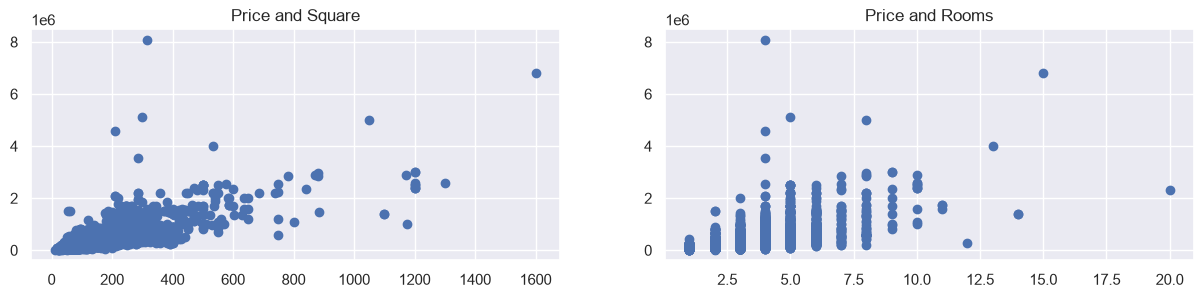

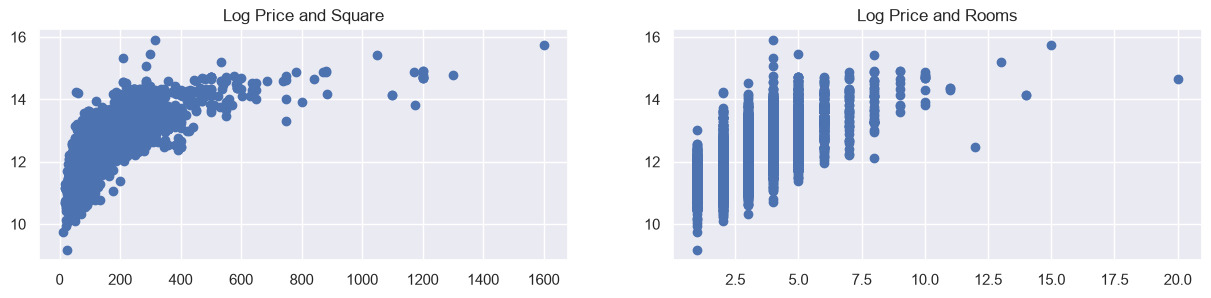

In [16]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 3))
ax1.scatter(data['square'], data['price'])
ax1.set_title('Price and Square')
ax2.scatter(data['rooms'], data['price'])
ax2.set_title('Price and Rooms')
plt.show()

data['log_price'] = np.log(data['price'])

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 3))
ax1.scatter(data['square'], data['log_price'])
ax1.set_title('Log Price and Square')
ax2.scatter(data['rooms'], data['log_price'])
ax2.set_title('Log Price and Rooms')
plt.show()


## 9. Declare inputs and target

In [17]:
targets = data['log_price']
inputs = data.drop(['price', 'log_price'], axis=1)


## 10. Train/test split

Splitting *before* outlier treatment, correlation checks, encoding, and
scaling ensures none of those steps see the test set — avoiding data
leakage.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    inputs, targets, test_size=0.2, random_state=42
)

print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)
print('y_train shape', y_train.shape)
print('y_test shape', y_test.shape)


X_train shape (31441, 11)
X_test shape (7861, 11)
y_train shape (31441,)
y_test shape (7861,)


## 11. Outlier treatment (IQR)

Bounds are computed **from `X_train` only**, then applied to both `X_train`
and `X_test`. Computing bounds only from training data avoids leaking test
information; applying the same bounds to `X_test` keeps train and test on a
comparable scale (clipping only the train set, as in the walkthrough
template, leaves outliers in the test set and can widen the train/test
performance gap).

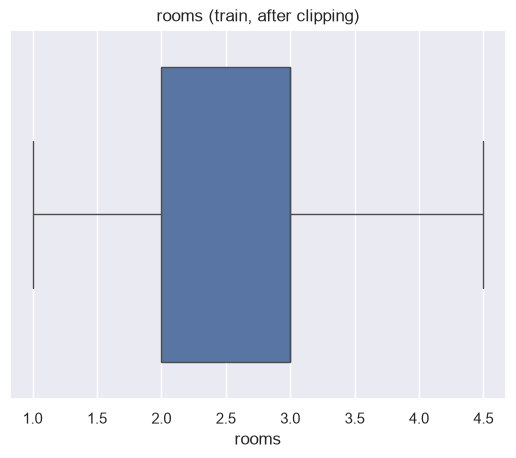

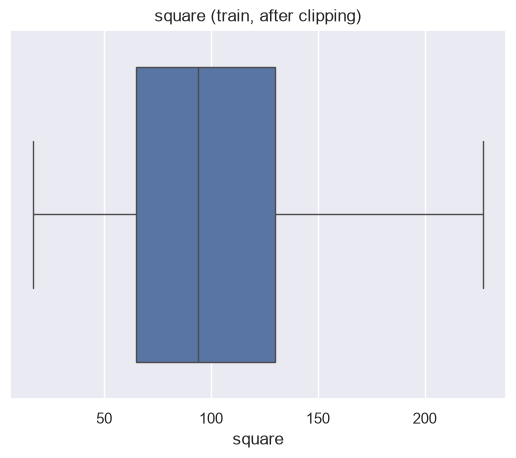

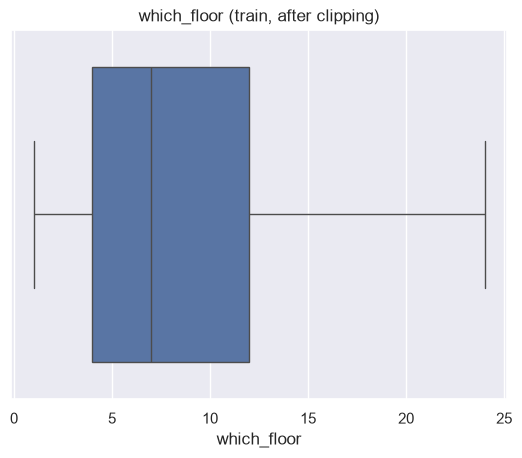

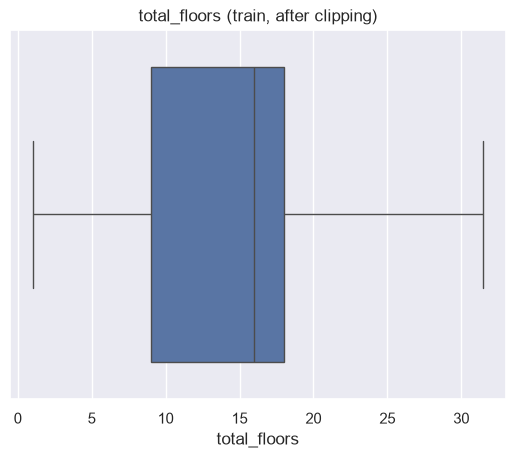

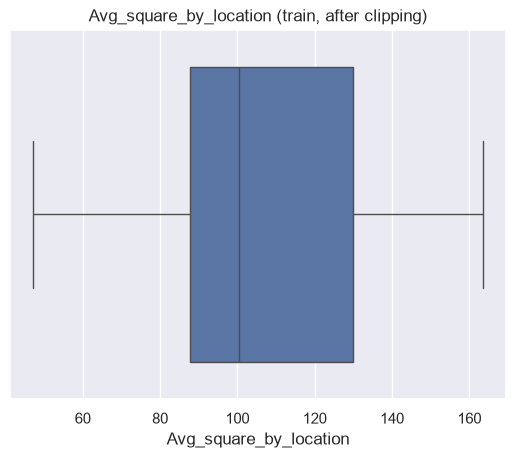

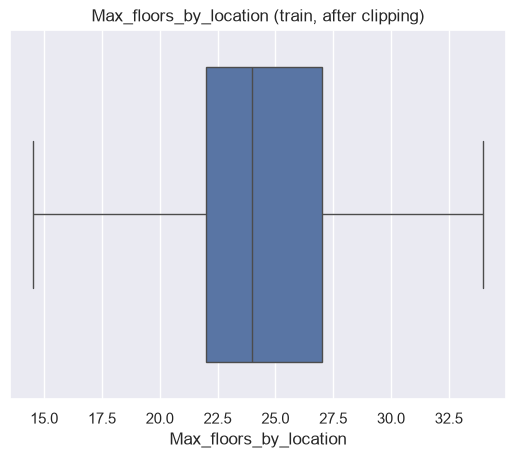

In [19]:
numeric_cols_for_outliers = X_train.select_dtypes(include='number').columns

q1 = X_train[numeric_cols_for_outliers].quantile(0.25)
q3 = X_train[numeric_cols_for_outliers].quantile(0.75)
IQR = q3 - q1

Lower = q1 - 1.5 * IQR
Upper = q3 + 1.5 * IQR

for col in numeric_cols_for_outliers:
    X_train[col] = np.where(X_train[col] > Upper[col], Upper[col], X_train[col])
    X_train[col] = np.where(X_train[col] < Lower[col], Lower[col], X_train[col])
    # apply the SAME train-derived bounds to the test set
    X_test[col] = np.where(X_test[col] > Upper[col], Upper[col], X_test[col])
    X_test[col] = np.where(X_test[col] < Lower[col], Lower[col], X_test[col])

    sns.boxplot(data=X_train, x=X_train[col])
    plt.title(f'{col} (train, after clipping)')
    plt.show()


## 12. Check distribution normality (Kolmogorov–Smirnov test)

This tells us whether to use Pearson or Spearman correlation next.

In [20]:
for col in X_train.select_dtypes(include=['int64', 'float64']).columns:
    stat, p_value = stats.kstest(X_train[col], 'norm')
    print(f'Column: {col}')
    print(f'p-value: {p_value}')
    print('Data looks normally distributed' if p_value > 0.05 else 'Data does not look normally distributed')
    print()

# All p-values are 0.0 -> none of the numeric features are normally distributed,
# so Spearman (rank-based, no normality assumption) is the right correlation
# measure to use rather than Pearson.


Column: rooms
p-value: 0.0
Data does not look normally distributed

Column: square
p-value: 0.0
Data does not look normally distributed

Column: which_floor
p-value: 0.0
Data does not look normally distributed

Column: total_floors
p-value: 0.0
Data does not look normally distributed

Column: Avg_square_by_location
p-value: 0.0
Data does not look normally distributed

Column: Max_floors_by_location
p-value: 0.0
Data does not look normally distributed



## 13. Correlation check (Spearman)

In [21]:
X_train.corr(numeric_only=True, method='spearman')


,rooms,square,which_floor,total_floors,Avg_square_by_location,Max_floors_by_location
rooms,1.000000,0.782784,0.107711,0.123724,0.212894,0.158574
square,0.782784,1.000000,0.276099,0.388563,0.385168,0.301917
which_floor,0.107711,0.276099,1.000000,0.610016,0.129071,0.167694
total_floors,0.123724,0.388563,0.610016,1.000000,0.199007,0.261277
Avg_square_by_location,0.212894,0.385168,0.129071,0.199007,1.000000,0.788085
Max_floors_by_location,0.158574,0.301917,0.167694,0.261277,0.788085,1.000000


## 14. Multicollinearity check (VIF)

VIF > ~5–10 signals a feature is highly explainable from the others and
inflates coefficient variance. We test the engineered/aggregate features
together with the raw features they were built from.

In [22]:
def calculate_vif(data, variables):
    vif_data = data[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    return pd.DataFrame({'Features': variables, 'VIF': vif_values})

vif_result = calculate_vif(
    X_train,
    ['square', 'which_floor', 'total_floors',
     'Avg_square_by_location', 'Max_floors_by_location']
)
vif_result


,Features,VIF
0,square,7.913847
1,which_floor,6.103793
2,total_floors,13.564490
3,Avg_square_by_location,65.666782
4,Max_floors_by_location,66.193517


## 15. Feature selection

`Avg_square_by_location` and `Max_floors_by_location` show very high VIF
(~65), meaning they're almost entirely explainable from the other features —
we drop them. `total_floors` and `rooms` are also dropped: `total_floors`
is highly correlated with `which_floor`, and `rooms` is highly correlated
with `square` (Spearman ≈ 0.78), so keeping both would add redundant,
collinear information without much new signal.

`location` is kept as a categorical feature, but it has 100+ distinct
values. One-hot encoding all of them would add 100+ mostly-sparse columns
and risks overfitting on a training set of this size, so we group any
location with fewer than 100 training examples into an `"Other"` bucket
before encoding.

In [23]:
selected_columns = ['location', 'square', 'which_floor',
                    'new_building', 'has_repair', 'has_bill_of_sale', 'has_mortgage']

X_train = X_train[selected_columns].copy()
X_test = X_test[selected_columns].copy()

# Collapse rare locations to reduce one-hot dimensionality / overfitting risk
location_counts = X_train['location'].value_counts()
common_locations = location_counts[location_counts >= 100].index

X_train['location'] = X_train['location'].where(X_train['location'].isin(common_locations), 'Other')
X_test['location'] = X_test['location'].where(X_test['location'].isin(common_locations), 'Other')

print(f"Reduced location categories from {len(location_counts)} to {X_train['location'].nunique()}")
X_train.head()


Reduced location categories from 111 to 44


,location,square,which_floor,new_building,has_repair,has_bill_of_sale,has_mortgage
31854,Əhmədli m.,55.0,5.0,No,Yes,Yes,Yes
35578,Memar Əcəmi m.,58.0,4.0,No,Yes,Yes,No
14993,Həzi Aslanov m.,133.0,15.0,Yes,Yes,Yes,No
37600,Nərimanov r.,48.0,5.0,No,Yes,Yes,No
18053,Nərimanov r.,80.0,8.0,Yes,Yes,Yes,No


## 16. Encode categorical variables (one-hot)

In [24]:
categorical_columns = X_train.select_dtypes(include=['object', 'category']).columns
numeric_columns = X_train.select_dtypes(include='number').columns

encoder = OneHotEncoder(
    drop='first',           # avoid the dummy-variable trap
    handle_unknown='ignore',# any unseen category in test -> all-zero row
    sparse_output=False,
    dtype=int
)

X_train_encoded = pd.DataFrame(
    encoder.fit_transform(X_train[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_train.index
)
X_test_encoded = pd.DataFrame(
    encoder.transform(X_test[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_test.index
)

X_train_final = pd.concat([X_train[numeric_columns], X_train_encoded], axis=1)
X_test_final = pd.concat([X_test[numeric_columns], X_test_encoded], axis=1)

X_train_final.head()


C:\Users\aksta\AppData\Local\Temp\ipykernel_728\3757328282.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(include=['object', 'category']).columns


,square,which_floor,location_28 May m.,location_7-ci mikrorayon q.,location_8 Noyabr m.,location_8-ci mikrorayon q.,location_9-cu mikrorayon q.,location_Azadlıq Prospekti m.,location_Ağ şəhər q.,location_Badamdar q.,...,location_Yeni Yasamal q.,location_İnşaatçılar m.,location_İçəri Şəhər m.,location_Şah İsmayıl Xətai m.,location_Əhmədli m.,location_Əhmədli q.,new_building_Yes,has_repair_Yes,has_bill_of_sale_Yes,has_mortgage_Yes
31854,55.0,5.0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,1
35578,58.0,4.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
14993,133.0,15.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,0
37600,48.0,5.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
18053,80.0,8.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,0


## 17. Scale the data

Fit the scaler on the training data only, then apply it to both sets.

In [25]:
scaler = StandardScaler()
scaler.fit(X_train_final)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_final), columns=X_train_final.columns, index=X_train_final.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_final), columns=X_test_final.columns, index=X_test_final.index
)

X_train_scaled.head()


,square,which_floor,location_28 May m.,location_7-ci mikrorayon q.,location_8 Noyabr m.,location_8-ci mikrorayon q.,location_9-cu mikrorayon q.,location_Azadlıq Prospekti m.,location_Ağ şəhər q.,location_Badamdar q.,...,location_Yeni Yasamal q.,location_İnşaatçılar m.,location_İçəri Şəhər m.,location_Şah İsmayıl Xətai m.,location_Əhmədli m.,location_Əhmədli q.,new_building_Yes,has_repair_Yes,has_bill_of_sale_Yes,has_mortgage_Yes
31854,-1.033308,-0.643798,-0.212221,-0.079405,-0.194054,-0.084136,-0.094963,-0.16313,-0.105022,-0.103306,...,-0.119956,-0.277564,-0.116358,-0.24123,5.668392,-0.09782,-1.764568,0.437955,0.550587,1.40649
35578,-0.969560,-0.846015,-0.212221,-0.079405,-0.194054,-0.084136,-0.094963,-0.16313,-0.105022,-0.103306,...,-0.119956,-0.277564,-0.116358,-0.24123,-0.176417,-0.09782,-1.764568,0.437955,0.550587,-0.71099
14993,0.624150,1.378366,-0.212221,-0.079405,-0.194054,-0.084136,-0.094963,-0.16313,-0.105022,-0.103306,...,-0.119956,-0.277564,-0.116358,-0.24123,-0.176417,-0.09782,0.566711,0.437955,0.550587,-0.71099
37600,-1.182055,-0.643798,-0.212221,-0.079405,-0.194054,-0.084136,-0.094963,-0.16313,-0.105022,-0.103306,...,-0.119956,-0.277564,-0.116358,-0.24123,-0.176417,-0.09782,-1.764568,0.437955,0.550587,-0.71099
18053,-0.502072,-0.037149,-0.212221,-0.079405,-0.194054,-0.084136,-0.094963,-0.16313,-0.105022,-0.103306,...,-0.119956,-0.277564,-0.116358,-0.24123,-0.176417,-0.09782,0.566711,0.437955,0.550587,-0.71099


## 18. Fit the linear regression model

In [26]:
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](49,)","[ 0.39,-0. , 0.05,..., 0.06, 0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](49,)","['square','which_floor','location_28 May m.',...,'has_repair_Yes', 'has_bill_of_sale_Yes','has_mortgage_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.19
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,49
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(49)


## 19. Coefficients and intercept

In [27]:
coef_table = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': reg.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Intercept:', reg.intercept_)
coef_table.head(15)


Intercept: 12.191138578815755


,Feature,Coefficient
0,square,0.385262
20,location_Masazır q.,-0.096292
46,has_repair_Yes,0.059486
32,location_Sahil m.,0.058168
45,new_building_Yes,0.057383
41,location_İçəri Şəhər m.,0.056319
25,location_Nəriman Nərimanov m.,0.055645
42,location_Şah İsmayıl Xətai m.,0.053517
15,location_Elmlər Akademiyası m.,0.052534
2,location_28 May m.,0.050268


## 20. Predict

In [28]:
y_pred = reg.predict(X_test_scaled)
y_pred_train = reg.predict(X_train_scaled)


## 21. Evaluate the model

We compare train vs. test metrics — a large gap would signal overfitting.

In [29]:
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

def evaluate(y_true_train, y_pred_train, y_true_test, y_pred_test, k):
    rows = []
    for name, y_true, y_pred, n in [
        ('Train', y_true_train, y_pred_train, len(y_true_train)),
        ('Test', y_true_test, y_pred_test, len(y_true_test)),
    ]:
        mae = metrics.mean_absolute_error(y_true, y_pred)
        mse = metrics.mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mape = metrics.mean_absolute_percentage_error(y_true, y_pred)
        r2 = metrics.r2_score(y_true, y_pred)
        adj_r2 = adjusted_r2(r2, n, k)
        rows.append([mae, mse, rmse, mape, r2, adj_r2])
    return pd.DataFrame(
        np.array(rows).T,
        index=['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Adjusted R2'],
        columns=['Train', 'Test']
    )

results_df = evaluate(y_train, y_pred_train, y_test, y_pred, X_train_scaled.shape[1])
results_df


,Train,Test
MAE,0.153162,0.152040
MSE,0.046622,0.047682
RMSE,0.215922,0.218362
MAPE,0.012498,0.012392
R2,0.841972,0.839450
Adjusted R2,0.841726,0.838442


## 22. Univariate analysis of each feature

Before trusting the full model, it's useful to see how much predictive
power each individual feature has on its own — this highlights which
variables are actually driving the fit vs. contributing noise.

In [30]:
uni_results = []
for col in X_train_scaled.columns:
    single_reg = LinearRegression()
    single_reg.fit(X_train_scaled[[col]], y_train)

    train_r2 = metrics.r2_score(y_train, single_reg.predict(X_train_scaled[[col]]))
    test_r2 = metrics.r2_score(y_test, single_reg.predict(X_test_scaled[[col]]))

    uni_results.append({'Variable': col, 'Train R2': train_r2, 'Test R2': test_r2})

uni_results_df = pd.DataFrame(uni_results).sort_values('Test R2', ascending=False)
uni_results_df.head(15)


,Variable,Train R2,Test R2
0,square,0.716808,0.717406
45,new_building_Yes,0.149310,0.166281
20,location_Masazır q.,0.073013,0.069759
1,which_floor,0.056768,0.068973
28,location_Nəsimi r.,0.024903,0.028804
2,location_28 May m.,0.024474,0.025676
42,location_Şah İsmayıl Xətai m.,0.024076,0.024812
29,location_Other,0.022982,0.023293
23,location_Nizami m.,0.019332,0.022325
46,has_repair_Yes,0.017027,0.021937


## 23. Reduced model using the top individual predictors

As a check, we refit using only the strongest single-variable predictors
from the univariate analysis above and compare performance to the full
model.

In [31]:
top_features = uni_results_df.head(5)['Variable'].tolist()
print('Top features:', top_features)

X_train_top = X_train_scaled[top_features]
X_test_top = X_test_scaled[top_features]

reg_top = LinearRegression()
reg_top.fit(X_train_top, y_train)

y_pred_top = reg_top.predict(X_test_top)
y_pred_train_top = reg_top.predict(X_train_top)

results_top_df = evaluate(y_train, y_pred_train_top, y_test, y_pred_top, X_train_top.shape[1])
results_top_df


Top features: ['square', 'new_building_Yes', 'location_Masazır q.', 'which_floor', 'location_Nəsimi r.']


,Train,Test
MAE,0.196922,0.195413
MSE,0.072056,0.071706
RMSE,0.268433,0.267780
MAPE,0.016097,0.015960
R2,0.755763,0.758557
Adjusted R2,0.755724,0.758403


## 24. Conclusions

- The full model explains roughly the variance shown in the **R²** row of
  the section 21 results table on the test set, with a train/test gap that's
  worth watching — a persistent large gap would suggest overfitting, most
  likely driven by the number of one-hot `location` columns relative to the
  training set size.
- Dropping `price_per_sqm` was essential — it's derived from the target and
  would otherwise have caused target leakage and an unrealistically high R².
- `Avg_square_by_location`, `Max_floors_by_location`, `total_floors`, and
  `rooms` were dropped due to high VIF / high correlation with features
  already in the model — keeping them would inflate coefficient variance
  without adding real signal.
- The reduced model (section 23) shows how much of the full model's
  performance comes from just its strongest individual predictors — useful
  context for deciding whether the extra one-hot `location` columns are
  worth the added complexity.

**Possible next steps:** try Ridge/Lasso regression to regularize the many
one-hot `location` coefficients, use k-fold cross-validation instead of a
single train/test split, and try target/frequency encoding for `location`
as an alternative to one-hot encoding.


In [32]:
# 25. Predict on a brand-new house

# Step 1: describe the new house using the RAW column names
# (must match your original data before encoding/scaling)
new_house = pd.DataFrame([{
    'square': 95,
    'which_floor': 6,
    'new_building': 'Yes',
    'location': 'Masazır q.'
}])

# Step 2: recreate the same 5 columns the reduced model expects.
# One-hot columns are 0/1 flags for "is it this category?"
new_house_features = pd.DataFrame({
    'square': [new_house['square'][0]],
    'new_building_Yes': [1 if new_house['new_building'][0] == 'Yes' else 0],
    'location_Masazır q.': [1 if new_house['location'][0] == 'Masazır q.' else 0],
    'which_floor': [new_house['which_floor'][0]],
    'location_Nəsimi r.': [1 if new_house['location'][0] == 'Nəsimi r.' else 0],
})

# Step 3: scale it using the SAME scaler you fit on training data
# (only the columns the scaler was fit on, in the same order)
new_house_scaled = pd.DataFrame(
    scaler.transform(
        pd.concat([new_house_features,
                   X_train_final.drop(columns=top_features, errors='ignore') * 0],
                  axis=1)[X_train_final.columns].fillna(0)
    ),
    columns=X_train_final.columns
)[top_features]

# Step 4: predict (model outputs LOG price, so convert back with exp)
predicted_log_price = reg_top.predict(new_house_scaled)
predicted_price = np.exp(predicted_log_price)

print(f"Predicted price: {predicted_price[0]:,.0f}")

Predicted price: 88,730
